In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("laotse/credit-risk-dataset")

print("Path to dataset files:", path)

/Users/vrushankhitenrawal/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/vrushankhitenrawal/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/vrushankhitenrawal/.cache/kagglehub/datasets/laotse/credit-risk-dataset/versions/1


In [6]:
df = pd.read_csv("credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [7]:
""""
Five things an ML Engineer thinks after getting the dataset
1. What do I have? shape, col, dtypes
2. Is it clean? -> nulls, duplicates, wrong values
3. What does it look like? -> distributions, value counts
4. Are there patterns? correlation, relationships
5. What needs fixing? before I can train model 

"""



'"\nFive things an ML Engineer thinks after getting the dataset\n1. What do I have? shape, col, dtypes\n2. Is it clean? -> nulls, duplicates, wrong values\n3. What does it look like? -> distributions, value counts\n4. Are there patterns? correlation, relationships\n5. What needs fixing? before I can train model \n\n'

In [8]:
# Answer to the first one now

# Size of the dataset
print(df.shape) # tells the shape of the dataset -> (rows, columns)

# column names + data types

print(df.info()) # tells col name, null values counts, type (int, float, object)

# now the basic statitics of the data
print(df.describe())
# min, max, mean, std for every mumber column

(32581, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None
         perso

In [9]:
# Now check if the dataset is clean 

print(df.isnull().sum(), "\n")

# Now check for duplicates here 
print("Here are the duplicate values: ")
print(df.duplicated().sum())

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64 

Here are the duplicate values: 
165


In [10]:
print(df["loan_status"].value_counts()) # check the target column

# see the actual values of cb_person_default_on_file
print(df["cb_person_default_on_file"].value_counts()) # object type contains text values 

loan_status
0    25473
1     7108
Name: count, dtype: int64
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64


In [11]:
# are there patterns in the dataset 

df.corr(numeric_only=True) # finds the patterns using corelation matrix

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.173202,0.163106,0.050787,0.012580,-0.021629,-0.042411,0.859133
person_income,0.173202,1.000000,0.134268,0.266820,0.000792,-0.144449,-0.254471,0.117987
person_emp_length,0.163106,0.134268,1.000000,0.113082,-0.056405,-0.082489,-0.054111,0.144699
loan_amnt,0.050787,0.266820,0.113082,1.000000,0.146813,0.105376,0.572612,0.041967
loan_int_rate,0.012580,0.000792,-0.056405,0.146813,1.000000,0.335133,0.120314,0.016696
loan_status,-0.021629,-0.144449,-0.082489,0.105376,0.335133,1.000000,0.379366,-0.015529
loan_percent_income,-0.042411,-0.254471,-0.054111,0.572612,0.120314,0.379366,1.000000,-0.031690
cb_person_cred_hist_length,0.859133,0.117987,0.144699,0.041967,0.016696,-0.015529,-0.031690,1.000000


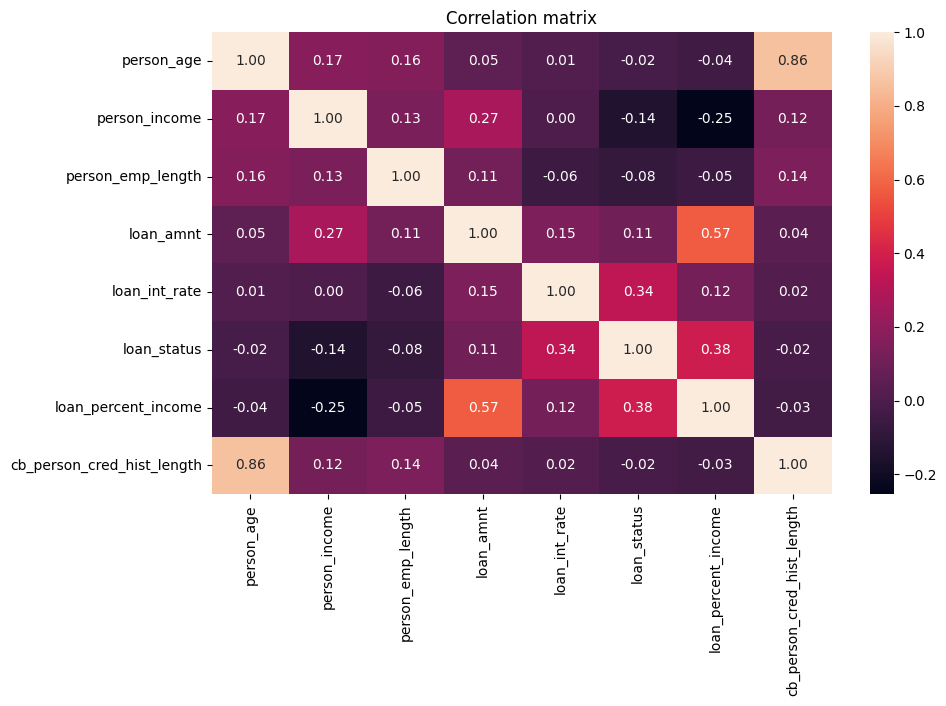

In [12]:
# Let's visualize using heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")
cmap="coolwarm"
plt.title("Correlation matrix")
plt.show()

In [14]:
# Now as per the information we got 

# The problems we have and how to fix it 

# Problem - 1. 3116 missing in loan_int_rate: fix - Fill with median 

# 2. 895 missing in person_emp_length - Fill with median

# 3. 165 duplicates - drop them 

# 4. cb_person_defualt_on_file is Y/N - Convert to 1/0

# 5. loan_grade, loan_intent, home_ownership are text - Convert to numbers

# 6. Class imbalance 78/22 - Handle during training


In [15]:
# Let's drop the duplicates

df = df.drop_duplicates()
df.shape

(32416, 12)

In [16]:
# Let's fill missing values with median 


# Fill the loan int rate with median missing values handling
df["loan_int_rate"] = df["loan_int_rate"].fillna(df["loan_int_rate"].median())

# fill person emp_length with median handling missing values 

df["person_emp_length"] = df["person_emp_length"].fillna(df["person_emp_length"].median())

In [17]:
# Verify no more missing values 

df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [18]:
# convert Y/N to 1/0

df["cb_person_default_on_file"] = df["cb_person_default_on_file"].map({"Y": 1, "N":0})

In [19]:
# now verify 

df["cb_person_default_on_file"].value_counts()

cb_person_default_on_file
0    26686
1     5730
Name: count, dtype: int64

In [20]:
df.select_dtypes(include="object").columns # this shows number of text cols remaining

Index(['person_home_ownership', 'loan_intent', 'loan_grade'], dtype='object')

In [21]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder() 


# using label encoder on the loan grade column as it has the data that follows a specific order

df["loan_grade"] = le.fit_transform(df["loan_grade"])

df["loan_grade"].value_counts()



loan_grade
0    10703
1    10387
2     6438
3     3620
4      963
5      241
6       64
Name: count, dtype: int64

In [23]:
# let's change the home_ownership and loan_intent columns through one hot encoding

df = pd.get_dummies(df, columns=["person_home_ownership", "loan_intent"], drop_first=True)

In [24]:
print(df.shape)
print(df.columns.tolist())

(32416, 18)
['person_age', 'person_income', 'person_emp_length', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']


In [25]:
# The new version of pandas while doing one hot encoding it creates the values in boolean now we have to convert this in 0,1

df = df.astype({col: int for col in df.select_dtypes(include="bool").columns})

In [26]:
df

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22,59000,123.0,3,35000,16.02,1,0.59,1,3,0,0,1,0,0,0,1,0
1,21,9600,5.0,1,1000,11.14,0,0.10,0,2,0,1,0,1,0,0,0,0
2,25,9600,1.0,2,5500,12.87,1,0.57,0,3,0,0,0,0,0,1,0,0
3,23,65500,4.0,2,35000,15.23,1,0.53,0,2,0,0,1,0,0,1,0,0
4,24,54400,8.0,2,35000,14.27,1,0.55,1,4,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,1.0,2,5800,13.16,0,0.11,0,30,0,0,0,0,0,0,1,0
32577,54,120000,4.0,0,17625,7.49,0,0.15,0,19,0,0,0,0,0,0,1,0
32578,65,76000,3.0,1,35000,10.99,1,0.46,0,28,0,0,1,0,1,0,0,0
32579,56,150000,5.0,1,15000,11.48,0,0.10,0,26,0,0,0,0,0,0,1,0


In [27]:
df.dtypes

person_age                       int64
person_income                    int64
person_emp_length              float64
loan_grade                       int64
loan_amnt                        int64
loan_int_rate                  float64
loan_status                      int64
loan_percent_income            float64
cb_person_default_on_file        int64
cb_person_cred_hist_length       int64
person_home_ownership_OTHER      int64
person_home_ownership_OWN        int64
person_home_ownership_RENT       int64
loan_intent_EDUCATION            int64
loan_intent_HOMEIMPROVEMENT      int64
loan_intent_MEDICAL              int64
loan_intent_PERSONAL             int64
loan_intent_VENTURE              int64
dtype: object

In [28]:
# feature scaling 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = ["person_age", "person_income", "person_emp_length", "loan_amnt", "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length"]

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [29]:
df[numeric_cols].describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
count,3.241600e+04,3.241600e+04,3.241600e+04,3.241600e+04,3.241600e+04,3.241600e+04,3.241600e+04
mean,2.244558e-16,1.402848e-17,-7.014242e-17,1.192421e-16,5.699072e-16,1.508062e-16,-1.122279e-16
std,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00
min,-1.219233e+00,-1.001242e+00,-1.165886e+00,-1.438300e+00,-1.814679e+00,-1.593946e+00,-9.389818e-01
25%,-7.470894e-01,-4.442443e-01,-6.769300e-01,-7.265716e-01,-8.188970e-01,-7.513307e-01,-6.926138e-01
50%,-2.749460e-01,-1.788552e-01,-1.879741e-01,-2.520858e-01,-7.999310e-03,-1.895873e-01,-4.462457e-01
75%,3.545785e-01,2.116655e-01,5.454598e-01,4.201026e-01,6.796419e-01,5.594040e-01,5.392265e-01
max,1.829603e+01,9.568563e+01,2.890490e+01,4.018287e+00,3.958912e+00,6.176838e+00,5.959324e+00


In [30]:
# Now let's split the data in train and test columns

# X- imput cols (everything except loan_status)
# y- target col (loan_status)

X=df.drop("loan_status", axis=1)
y = df["loan_status"]

print(X.shape)
print(y.shape)
print(y.value_counts())

(32416, 17)
(32416,)
loan_status
0    25327
1     7089
Name: count, dtype: int64


In [31]:
# Now we will split this into train and test sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [32]:
# Verifying 

print(X_train.shape)
print(X_test.shape)

(25932, 17)
(6484, 17)


In [33]:
# Let's train the model on RandomForestClassifier

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [34]:
# Prediction time 

y_pred = model.predict(X_test)
y_pred

array([0, 1, 0, ..., 0, 0, 0])

In [35]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("\nClassification Report: \n", classification_report(y_test, y_pred))
print("\n Confusion matrix: \n", confusion_matrix(y_test, y_pred))

Accuracy:  0.9164096236890809

Classification Report: 
               precision    recall  f1-score   support

           0       0.91      0.99      0.95      5073
           1       0.95      0.65      0.77      1411

    accuracy                           0.92      6484
   macro avg       0.93      0.82      0.86      6484
weighted avg       0.92      0.92      0.91      6484


 Confusion matrix: 
 [[5030   43]
 [ 499  912]]


In [36]:
# Training again with the class_weight = balanced parameter of RandomForest

model_balanced = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, class_weight='balanced')

model_balanced.fit(X_train, y_train)



RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [37]:
y_pred_balanced = model_balanced.predict(X_test)

In [38]:
# Now the scores for the balanced model 
print("Accuracy: ", accuracy_score(y_test, y_pred_balanced))
print("\nClassification Report: \n", classification_report(y_test, y_pred_balanced))
print("\n Confusion matrix: \n", confusion_matrix(y_test, y_pred_balanced))

Accuracy:  0.884176434299815

Classification Report: 
               precision    recall  f1-score   support

           0       0.94      0.92      0.93      5073
           1       0.72      0.77      0.74      1411

    accuracy                           0.88      6484
   macro avg       0.83      0.84      0.83      6484
weighted avg       0.89      0.88      0.89      6484


 Confusion matrix: 
 [[4643  430]
 [ 321 1090]]


In [40]:
# Let's save the model 

import pickle

with open("../artifacts/models/model.pkl", "wb") as f: 
    pickle.dump(model_balanced, f)

print("Model saved successfully!")

Model saved successfully!


In [42]:
# Save metrics

import json


metrics = {
    "accuracy": accuracy_score(y_test, y_pred_balanced), 
    "classification_report": classification_report(y_test, y_pred_balanced, output_dict=True)
}

with open("../artifacts/metrics/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("Metrics saved successfully!")

Metrics saved successfully!


In [43]:
import os

print(os.path.exists("../artifacts/models/model.pkl"))
print(os.path.exists("../artifacts/metrics/metrics.json"))

True
True
